In [69]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.layers import TextVectorization
import os

# Direction for data
tfds.core.constants.DATA_DIR = 'D:/Tensorflow_datasets/wmt14'

# Get DataSet
examples, metadata = tfds.load('wmt14_translate/de-en', with_info=True, as_supervised=True)
train_examples, val_examples = examples['train'], examples['validation']
train_examples = train_examples.take(100000)

# Split DE vs EN
de_texts = []
en_texts = []

for de, en in train_examples:
    de_texts.append(de.numpy().decode('utf-8', errors='ignore'))
    en_texts.append(en.numpy().decode('utf-8', errors='ignore'))

# Filtering truely sentences
def safe_decode(text):
    try:
        text.encode('utf-8').decode('utf-8')
        return True
    except:
        return False

de_texts_clean = [t for t in de_texts if safe_decode(t)]
en_texts_clean = [t for t in en_texts if safe_decode(t)]

# Make vocab
source_vocab = sorted(list(set(' '.join(en_texts_clean).split())))
target_vocab = sorted(list(set(' '.join(de_texts_clean).split())))

# Transform Dictionary to Index
idx_to_word_target = {i: word for i, word in enumerate(target_vocab)}
word_to_idx_target = {word: i for i, word in enumerate(target_vocab)}

# Tokenizer
vocab_size = 8000
sequence_length = 50

source_vectorizer = TextVectorization(
    max_tokens=vocab_size,
    output_mode="int",
    output_sequence_length=sequence_length)

target_vectorizer = TextVectorization(
    max_tokens=vocab_size,
    output_mode="int",
    output_sequence_length=sequence_length)

# Adapting
source_vectorizer.adapt(en_texts_clean)
target_vectorizer.adapt(de_texts_clean)

# Simple test
example_input = "I love transformers."
vectorized = source_vectorizer(example_input)
print("Tokenized:", vectorized)


Tokenized: tf.Tensor(
[  19 1321    1    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0], shape=(50,), dtype=int64)


In [70]:
# Spetial Token for starting and ending
start_token = tf.constant([1], dtype=tf.int64)
end_token = tf.constant([2], dtype=tf.int64)

def process_pair(de_text, en_text):
    # Vectorize
    en_vector = source_vectorizer(en_text)
    de_vector = target_vectorizer(de_text)

    # Add Start-End token
    de_inp = tf.concat([start_token, de_vector[:-1]], axis=0)  # decoder input
    de_tar = tf.concat([de_vector, end_token], axis=0)         # target output

    return {
        "encoder_input": en_vector,
        "decoder_input": de_inp
    }, de_tar


In [71]:
BUFFER_SIZE = 20000
BATCH_SIZE = 64

train_dataset = tf.data.Dataset.from_tensor_slices((de_texts, en_texts))
train_dataset = train_dataset.map(lambda de, en: process_pair(de, en))
train_dataset = train_dataset.cache()
train_dataset = train_dataset.shuffle(BUFFER_SIZE).padded_batch(BATCH_SIZE, padded_shapes=({
    "encoder_input": [None],
    "decoder_input": [None]
}, [None]))
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)


In [72]:
for batch in train_dataset.take(1):
    print("Encoder input shape:", batch[0]["encoder_input"].shape)
    print("Decoder input shape:", batch[0]["decoder_input"].shape)
    print("Target shape:", batch[1].shape)


Encoder input shape: (64, 50)
Decoder input shape: (64, 50)
Target shape: (64, 51)


In [73]:
import numpy as np
import tensorflow as tf

class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, position, d_model):
        super().__init__()
        self.pos_encoding = self._positional_encoding(position, d_model)

    def _positional_encoding(self, position, d_model):
        angle_rads = self._get_angles(
            np.arange(position)[:, np.newaxis],   # (pos, 1)
            np.arange(d_model)[np.newaxis, :],    # (1, d_model)
            d_model
        )

        # Sinusoidal pattern: sin for even dimensions, cos for odd dimensions
        angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])  
        angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])  

        pos_encoding = angle_rads[np.newaxis, ...]  # (1, position, d_model)
        return tf.cast(pos_encoding, dtype=tf.float32)

    def _get_angles(self, pos, i, d_model):
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        return pos * angle_rates

    def call(self, inputs):
        return inputs + self.pos_encoding[:, :tf.shape(inputs)[1], :]


In [74]:
def scaled_dot_product_attention(q, k, v, mask=None):
    """
    q, k, v: tensors with shape (..., seq_len_q, depth)
    mask: (optional) tensor with shape (..., seq_len_q, seq_len_k)
    """
    matmul_qk = tf.matmul(q, k, transpose_b=True)  # (..., seq_len_q, seq_len_k)

    # scale the dot products
    dk = tf.cast(tf.shape(k)[-1], tf.float32)
    scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)

    # apply mask if exists (e.g. padding mask or look-ahead mask)
    if mask is not None:
        scaled_attention_logits += (mask * -1e9)  # -∞ makes softmax 0

    # softmax over last axis (seq_len_k) → attention weights
    attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)  # (..., seq_len_q, seq_len_k)

    # output → weighted sum of values
    output = tf.matmul(attention_weights, v)  # (..., seq_len_q, depth_v)

    return output, attention_weights


In [75]:
class MultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        assert d_model % num_heads == 0  # Be divisible

        self.depth = d_model // num_heads  # Depth of each Head

        self.wq = tf.keras.layers.Dense(d_model)  # Projection layer for Q
        self.wk = tf.keras.layers.Dense(d_model)  # Projection layer for k
        self.wv = tf.keras.layers.Dense(d_model)  # Projection layer for v

        self.dense = tf.keras.layers.Dense(d_model)  # Final output after concat

    def split_heads(self, x, batch_size):
        """
        تقسیم بردار به چند Head → تغییر شکل از (batch, seq_len, d_model)
        به (batch, num_heads, seq_len, depth)
        """
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])  # Moving axes

    def call(self, v, k, q, mask=None):
        batch_size = tf.shape(q)[0]

        q = self.wq(q)  # (batch, seq_len, d_model)
        k = self.wk(k)
        v = self.wv(v)

        q = self.split_heads(q, batch_size)  # (batch, heads, seq_len_q, depth)
        k = self.split_heads(k, batch_size)
        v = self.split_heads(v, batch_size)

        # Now attention for each head separately
        scaled_attention, attention_weights = scaled_dot_product_attention(q, k, v, mask)

        # برگردوندن شکل به حالت اولیه
        scaled_attention = tf.transpose(scaled_attention, perm=[0, 2, 1, 3])  # (batch, seq_len_q, heads, depth)
        concat_attention = tf.reshape(scaled_attention, (batch_size, -1, self.d_model))  # (batch, seq_len_q, d_model)

        output = self.dense(concat_attention)  # Final linear projection
        return output, attention_weights

In [76]:
class EncoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff, dropout_rate=0.1):
        super().__init__()
        self.mha = MultiHeadAttention(d_model, num_heads)
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(dff, activation='relu'),  # hidden layer 
            tf.keras.layers.Dense(d_model)                  # return to d_model
        ])

        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)

        self.dropout1 = tf.keras.layers.Dropout(dropout_rate)
        self.dropout2 = tf.keras.layers.Dropout(dropout_rate)

    def call(self, x, training, mask=None):
        # ----- 1. Multi-head Self Attention -----
        attn_output, _ = self.mha(x, x, x, mask)      # (batch, seq_len, d_model)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(x + attn_output)       # Add + Norm

        # ----- 2. Feed Forward -----
        ffn_output = self.ffn(out1)                   # (batch, seq_len, d_model)
        ffn_output = self.dropout2(ffn_output, training=training)
        out2 = self.layernorm2(out1 + ffn_output)     # Add + Norm

        return out2


In [77]:
class DecoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff, dropout_rate=0.1):
        super().__init__()
        self.mha1 = MultiHeadAttention(d_model, num_heads)  # masked self-attn
        self.mha2 = MultiHeadAttention(d_model, num_heads)  # encoder-decoder attn

        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(dff, activation='relu'),
            tf.keras.layers.Dense(d_model)
        ])

        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm3 = tf.keras.layers.LayerNormalization(epsilon=1e-6)

        self.dropout1 = tf.keras.layers.Dropout(dropout_rate)
        self.dropout2 = tf.keras.layers.Dropout(dropout_rate)
        self.dropout3 = tf.keras.layers.Dropout(dropout_rate)

    def call(self, x, enc_output, training, look_ahead_mask=None, padding_mask=None):
        # x: (batch, target_seq_len, d_model)
        # enc_output: (batch, input_seq_len, d_model)

        # 1️⃣ Masked Multi-head self-attention (decoder only sees past tokens)
        attn1, attn_weights_block1 = self.mha1(x, x, x, look_ahead_mask)
        attn1 = self.dropout1(attn1, training=training)
        out1 = self.layernorm1(attn1 + x)

        # 2️⃣ Multi-head encoder-decoder attention (queries = decoder, keys/values = encoder output)
        attn2, attn_weights_block2 = self.mha2(enc_output, enc_output, out1, padding_mask)
        attn2 = self.dropout2(attn2, training=training)
        out2 = self.layernorm2(attn2 + out1)

        # 3️⃣ Feed-forward network
        ffn_output = self.ffn(out2)
        ffn_output = self.dropout3(ffn_output, training=training)
        out3 = self.layernorm3(ffn_output + out2)

        return out3, attn_weights_block1, attn_weights_block2


In [78]:
class Encoder(tf.keras.layers.Layer):
    def __init__(self, num_layers, d_model, num_heads, dff,
                 input_vocab_size, maximum_position_encoding, dropout_rate=0.1):
        super().__init__()

        self.d_model = d_model
        self.num_layers = num_layers

        self.embedding = tf.keras.layers.Embedding(input_vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(maximum_position_encoding, d_model)

        self.enc_layers = [
            EncoderLayer(d_model, num_heads, dff, dropout_rate)
            for _ in range(num_layers)
        ]

        self.dropout = tf.keras.layers.Dropout(dropout_rate)

    def call(self, x, training, mask=None):
        seq_len = tf.shape(x)[1]

        # 1. Embed inputs
        x = self.embedding(x)  # (batch, seq_len, d_model)
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))  # scale embeddings
        x = self.pos_encoding(x)  # (batch, seq_len, d_model)

        x = self.dropout(x, training=training)

        # 2. Pass through N encoder layers
        for i in range(self.num_layers):
            x = self.enc_layers[i](x, training=training, mask=mask)

        return x  # (batch, seq_len, d_model)


In [79]:
class Decoder(tf.keras.layers.Layer):
    def __init__(self, num_layers, d_model, num_heads, dff,
                 target_vocab_size, maximum_position_encoding, dropout_rate=0.1):
        super().__init__()

        self.d_model = d_model
        self.num_layers = num_layers

        self.embedding = tf.keras.layers.Embedding(target_vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(maximum_position_encoding, d_model)

        self.dec_layers = [
            DecoderLayer(d_model, num_heads, dff, dropout_rate)
            for _ in range(num_layers)
        ]

        self.dropout = tf.keras.layers.Dropout(dropout_rate)

    def call(self, x, enc_output, training,
             look_ahead_mask=None, padding_mask=None):
        seq_len = tf.shape(x)[1]
        attention_weights = {}

        # 1. Embed
        x = self.embedding(x)  # (batch, target_seq_len, d_model)
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        x = self.pos_encoding(x)

        x = self.dropout(x, training=training)

        # 2. Pass through decoder layers
        for i in range(self.num_layers):
            x, block1, block2 = self.dec_layers[i](
              x,
              enc_output,
              training=training,
              look_ahead_mask=look_ahead_mask,
              padding_mask=padding_mask
            )


            attention_weights[f"decoder_layer{i+1}_block1"] = block1
            attention_weights[f"decoder_layer{i+1}_block2"] = block2

        # 3. Final decoder output + attention weights for analysis
        return x, attention_weights


In [80]:
class Transformer(tf.keras.Model):
    def __init__(self, num_layers, d_model, num_heads, dff,
                 input_vocab_size, target_vocab_size,
                 pe_input, pe_target, dropout_rate=0.1):
        super().__init__()

        self.encoder = Encoder(num_layers, d_model, num_heads, dff,
                               input_vocab_size, pe_input, dropout_rate)

        self.decoder = Decoder(num_layers, d_model, num_heads, dff,
                               target_vocab_size, pe_target, dropout_rate)

        self.final_layer = tf.keras.layers.Dense(target_vocab_size)

    def call(self, inputs, training, enc_padding_mask=None,
             look_ahead_mask=None, dec_padding_mask=None):

        inp, tar = inputs  # input = English sentence, tar = German sentence (decoder input)

        # 1️⃣ Encoder
        enc_output = self.encoder(inp, training=training, mask=enc_padding_mask)

        # 2️⃣ Decoder
        dec_output, attention_weights = self.decoder(
            tar, enc_output, training=training,
            look_ahead_mask=look_ahead_mask,
            padding_mask=dec_padding_mask)

        # 3️⃣ Final Linear layer → Predict next token
        final_output = self.final_layer(dec_output)  # (batch, tar_seq_len, target_vocab_size)

        return final_output, attention_weights


In [81]:
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True, reduction='none')

def loss_function(real, pred):
    mask = tf.math.logical_not(tf.math.equal(real, 0))  # Where real != 0
    loss_ = loss_object(real, pred)

    mask = tf.cast(mask, dtype=loss_.dtype)
    loss_ *= mask  # Only calculate loss where real ≠ padding

    return tf.reduce_sum(loss_) / tf.reduce_sum(mask)


In [82]:
def accuracy_function(real, pred):
    predictions = tf.argmax(pred, axis=2)
    matches = tf.equal(real, predictions)
    mask = tf.math.logical_not(tf.math.equal(real, 0))
    matches = tf.math.logical_and(mask, matches)

    return tf.reduce_sum(tf.cast(matches, tf.float32)) / tf.reduce_sum(tf.cast(mask, tf.float32))


In [83]:
class CustomSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, d_model, warmup_steps=4000):
        super().__init__()
        self.d_model = tf.cast(d_model, tf.float32)
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = tf.cast(step, tf.float32)

        arg1 = tf.math.rsqrt(step)
        arg2 = step * (self.warmup_steps ** -1.5)
        return tf.math.rsqrt(self.d_model) * tf.math.minimum(arg1, arg2)


In [84]:
learning_rate = CustomSchedule(d_model=512)

optimizer = tf.keras.optimizers.Adam(
    learning_rate,
    beta_1=0.9, beta_2=0.98,
    epsilon=1e-9)


In [85]:
def create_padding_mask(seq):
    mask = tf.cast(tf.math.equal(seq, 0), tf.float32)
    return mask[:, tf.newaxis, tf.newaxis, :]  # (batch, 1, 1, seq_len)

def create_look_ahead_mask(size):
    return 1 - tf.linalg.band_part(tf.ones((size, size)), -1, 0)

def create_masks(inp, tar):
    # Encoder padding mask
    enc_padding_mask = create_padding_mask(inp)

    # Decoder masks
    dec_padding_mask = create_padding_mask(inp)

    look_ahead_mask = create_look_ahead_mask(tf.shape(tar)[1])
    dec_target_padding_mask = create_padding_mask(tar)
    combined_mask = tf.maximum(dec_target_padding_mask, look_ahead_mask)

    return enc_padding_mask, combined_mask, dec_padding_mask


In [86]:
train_loss = tf.keras.metrics.Mean(name="train_loss")
train_accuracy = tf.keras.metrics.Mean(name="train_accuracy")

In [87]:
@tf.function
def train_step(inp, tar):
    tar_inp = tar[:, :-1]       # All tokens except the last → decoder input
    tar_real = tar[:, 1:]       # All tokens except the first → real target

    enc_padding_mask, combined_mask, dec_padding_mask = create_masks(inp, tar_inp)

    with tf.GradientTape() as tape:
        predictions, _ = transformer(
            (inp, tar_inp),
            training=True,
            enc_padding_mask=enc_padding_mask,
            look_ahead_mask=combined_mask,
            dec_padding_mask=dec_padding_mask
        )

        loss = loss_function(tar_real, predictions)

    gradients = tape.gradient(loss, transformer.trainable_variables)
    optimizer.apply_gradients(zip(gradients, transformer.trainable_variables))

    train_loss.update_state(loss)
    train_accuracy.update_state(accuracy_function(tar_real, predictions))


In [88]:
transformer = Transformer(
    num_layers=2,
    d_model=512,
    num_heads=8,
    dff=2048,
    input_vocab_size=source_vectorizer.vocabulary_size(),
    target_vocab_size=target_vectorizer.vocabulary_size(),
    pe_input=1000,
    pe_target=1000,
    dropout_rate=0.1
)



for (batch, (inp, tar)) in enumerate(train_dataset):
    encoder_input = inp["encoder_input"]
    decoder_input = inp["decoder_input"]

    train_step(encoder_input, tar)  # tar is the real target


In [89]:
EPOCHS = 60  # maximum of epochs
PATIENCE = 5  
best_accuracy = 0
patience_counter = 0

loss_history = []
accuracy_history = []

for epoch in range(EPOCHS):
    print(f"\nStarting epoch {epoch+1}/{EPOCHS}...")
    train_loss.reset_state()
    train_accuracy.reset_state()

    for (batch, (inp, tar)) in enumerate(train_dataset):
        encoder_input = inp["encoder_input"]
        decoder_input = inp["decoder_input"]

        train_step(encoder_input, tar)

    epoch_loss = train_loss.result().numpy()
    epoch_accuracy = train_accuracy.result().numpy()

    loss_history.append(epoch_loss)
    accuracy_history.append(epoch_accuracy)

    print(f"Epoch {epoch+1}: Loss={epoch_loss:.4f}, Accuracy={epoch_accuracy:.4f}")

    # Early Stopping Logic
    if epoch_accuracy > best_accuracy:
        best_accuracy = epoch_accuracy
        patience_counter = 0  # Accuracy improved → zero it
    else:
        patience_counter += 1  # Accuracy did not improve → Count it

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping triggered after {epoch+1} epochs! 🚀")
        break




Starting epoch 1/60...
Epoch 1: Loss=4.0119, Accuracy=0.3295

Starting epoch 2/60...
Epoch 2: Loss=3.4842, Accuracy=0.3757

Starting epoch 3/60...
Epoch 3: Loss=3.1326, Accuracy=0.4118

Starting epoch 4/60...
Epoch 4: Loss=2.8667, Accuracy=0.4418

Starting epoch 5/60...
Epoch 5: Loss=2.6623, Accuracy=0.4660

Starting epoch 6/60...
Epoch 6: Loss=2.4888, Accuracy=0.4874

Starting epoch 7/60...
Epoch 7: Loss=2.3376, Accuracy=0.5071

Starting epoch 8/60...
Epoch 8: Loss=2.2008, Accuracy=0.5251

Starting epoch 9/60...
Epoch 9: Loss=2.0770, Accuracy=0.5423

Starting epoch 10/60...
Epoch 10: Loss=1.9650, Accuracy=0.5578

Starting epoch 11/60...
Epoch 11: Loss=1.8621, Accuracy=0.5728

Starting epoch 12/60...
Epoch 12: Loss=1.7663, Accuracy=0.5874

Starting epoch 13/60...
Epoch 13: Loss=1.6783, Accuracy=0.6012

Starting epoch 14/60...
Epoch 14: Loss=1.5980, Accuracy=0.6140

Starting epoch 15/60...
Epoch 15: Loss=1.5220, Accuracy=0.6268

Starting epoch 16/60...
Epoch 16: Loss=1.4537, Accuracy=0

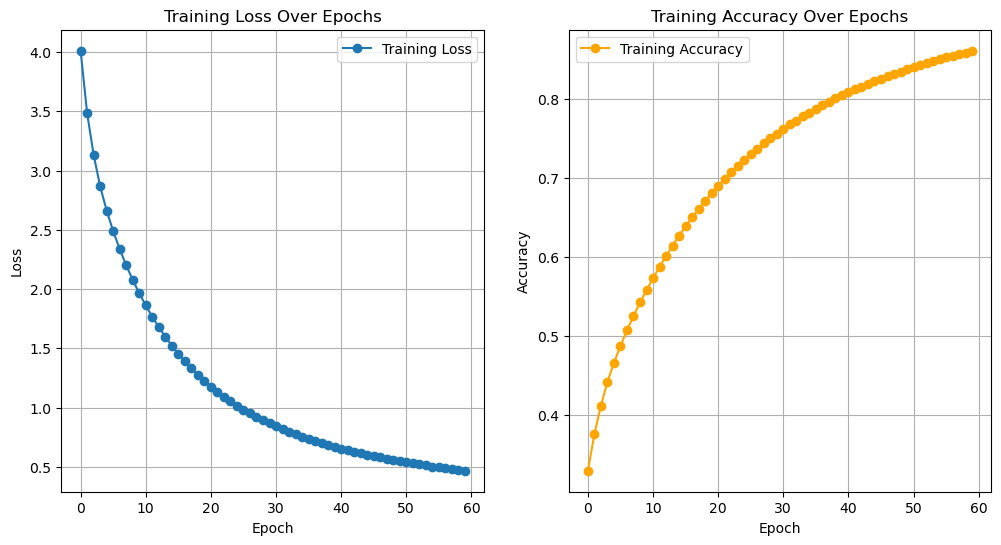

In [90]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# 📈  Loss
plt.subplot(1, 2, 1)
plt.plot(loss_history, marker='o', label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.grid(True)
plt.legend()

# 📈  Accuracy
plt.subplot(1, 2, 2)
plt.plot(accuracy_history, marker='o', color='orange', label='Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy Over Epochs')
plt.grid(True)
plt.legend()

plt.show()


In [91]:
def evaluate(inp_sentence):
    # 1. Input sentence preprocessing
    inp_sentence = tf.convert_to_tensor([inp_sentence])
    inp_sentence = source_vectorizer(inp_sentence)

    encoder_input = inp_sentence

    # 2. Prepare the initial decoder input: just the start token
    start_token = tf.constant([1], dtype=tf.int64)  
    end_token = tf.constant([2], dtype=tf.int64)

    decoder_input = tf.expand_dims(start_token, 0)  # (batch=1, 1)

    output = decoder_input  

    for i in range(50):  # Predict at least 50 tokens
        enc_padding_mask, combined_mask, dec_padding_mask = create_masks(
            encoder_input, output)

        # 3. One-step ahead forecasting
        predictions, attention_weights = transformer(
            (encoder_input, output),
            training=False,
            enc_padding_mask=enc_padding_mask,
            look_ahead_mask=combined_mask,
            dec_padding_mask=dec_padding_mask)

        # 4. Get the last predicted token
        predictions = predictions[:, -1:, :]  # Only the last output
        predicted_id = tf.argmax(predictions, axis=-1)

        # If the end token is predicted, the translation is complete.
        if tf.equal(predicted_id, end_token):
            break

        # Add prediction to output
        output = tf.concat([output, predicted_id], axis=-1)

    return tf.squeeze(output, axis=0), attention_weights


In [92]:
def translate(sentence):
    result, attention_weights = evaluate(sentence)

    decoded_sentence = []
    for idx in result.numpy():
        word = idx_to_word_target.get(idx, '')
        if word and word != '[PAD]' and word != '[UNK]':
            decoded_sentence.append(word)

    final_translation = ' '.join(decoded_sentence)

    print(f'Input: {sentence}')
    print(f'Predicted translation: {final_translation}')


In [93]:
translate("I love deep learning.")

Input: I love deep learning.
Predicted translation: !! "" "$buf !! "Jardim !!!!!!!! "+ "Ja", "Abfall "ALPENAUSSICHT" "...journalists..." ""Das "Babywell" "...dolls..." !!!!!!!! "+ "Ja", !! !!!!!!!! "+ "Ja", !! !! !!!!!!!! "+ "Ja", "It ""Das ""> (Astrium-Tochtergesellschaft !! !!!!!!!!!!! ", "%s" "...spelling..." ") "Mainterrasse"angeführt !Dekorationsartikel, "Messpunkt-Details" !!!!!!!! "...costochondritis..." !! "" "1. ""Das "Betrug "-" ""> ""Das "1.


In [94]:
translate("How are you?")

Input: How are you?
Predicted translation: !! "...by !! "...basketball..." !! "Als !! "...basketball..." !! "...african !! ".....t ""Haben !! !! "*"


In [95]:
translate("me?")

Input: me?
Predicted translation: !! "APN" "Altwirt" "APN" !Dekorationsartikel, "Altwirt" "APN" !Hans "Altwirt" "...expeditions..." "Airguns" "SWIFT-Abkommen" "APN" "Altwirt" "Airguns" "Altwirt" "Airguns" "Altwirt" "Airguns" "Altwirt" "Airguns" "Altwirt" "Altwirt" "APN" "Altwirt" "APN" "Analyse "Altwirt" "Altwirt" "Altwirt" "Altwirt" "Altwirt" "Altwirt" "Altwirt" "APN" !Dekorationsartikel, "Altwirt" "APN" !Dekorationsartikel, "Altwirt" "Analyse "APN" "Altwirt" "Altwirt" "Altwirt" "Altwirt" "Altwirt" "Altwirt" "Altwirt" "Altwirt" "Altwirt"
